In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv("train.csv", usecols=['Age', 'Fare', 'Survived'])

In [5]:
df.dropna(inplace=True)
# dropping the missing value

In [6]:
df.shape

(714, 3)

In [7]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [8]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [9]:
X

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
885,39.0,29.1250
886,27.0,13.0000
887,19.0,30.0000
889,26.0,30.0000


In [10]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
885,0
886,0
887,1
889,1


In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [12]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [13]:
# creating the model
clf= DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6293706293706294

In [14]:
# cross validation scoring
np.mean(cross_val_score(clf,X,y,cv=10,scoring='accuracy'))

np.float64(0.6261345852895148)

#Applying the Discretizer()

In [33]:
#creating the object
kbin_age = KBinsDiscretizer(n_bins=19, encode="ordinal",strategy="quantile")
kbin_fare = KBinsDiscretizer(n_bins=15, encode="ordinal",strategy="quantile")

In [34]:
#creating the column transformer
trf = ColumnTransformer([
    ('first', kbin_age,[0]),
    ('second', kbin_fare,[1])
])

In [35]:
# training and creating new x_train_trf
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [36]:
# now lets use different methods of named_transformers_
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=19),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [37]:
trf.named_transformers_['first']

KBinsDiscretizer(encode='ordinal', n_bins=19)

In [38]:
trf.named_transformers_['second']

KBinsDiscretizer(encode='ordinal', n_bins=15)

In [39]:
trf.named_transformers_['first'].n_bins_

array([19])

In [40]:
trf.named_transformers_['second'].n_bins_

array([15])

In [41]:
# you can also check bin_edges which tells you the range
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  4.  , 15.  , 18.  , 19.  , 21.  , 23.  , 24.  , 26.  ,
              28.  , 29.  , 31.  , 33.  , 35.  , 38.  , 41.  , 45.  , 49.  ,
              56.  , 80.  ])                                                ],
      dtype=object)

In [42]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

In [43]:
# now since these are in numpy array need to convert them into dataframe
output = pd.DataFrame({
    'age': X_train['Age'],
    'age_trf': X_train_trf[:,0],
    'fare': X_train['Fare'],
    'fare_trf': X_train_trf[:,1]
    })

In [44]:
output['age_labels'] =pd.cut(x=X_train['Age'],
                             bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_label'] = pd.cut(x=X_train['Fare'],
                              bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [45]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_label
51,21.0,5.0,7.8000,2.0,"(19.0, 21.0]","(7.775, 7.896]"
632,32.0,11.0,30.5000,10.0,"(31.0, 33.0]","(26.55, 31.275]"
297,2.0,0.0,151.5500,14.0,"(0.42, 4.0]","(108.9, 512.329]"
421,21.0,5.0,7.7333,1.0,"(19.0, 21.0]","(7.25, 7.775]"
581,39.0,14.0,110.8833,14.0,"(38.0, 41.0]","(108.9, 512.329]"


In [50]:
# now again using the model decision tree
clf= DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)
y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred2)

0.6293706293706294

In [60]:
# now lets conform using cross-val-score
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10, scoring='accuracy'))

np.float64(0.6288732394366197)

In [69]:
def discretize(bins,strategy):
  kbin_age = KBinsDiscretizer(n_bins=bins, encode="ordinal",strategy=strategy)
  kbin_fare = KBinsDiscretizer(n_bins=bins, encode="ordinal",strategy=strategy)

  trf = ColumnTransformer([
      ('first', kbin_age,[0]),
      ('second', kbin_fare,[1])
  ])

  X_trf = trf.fit_transform(X)

  print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10, scoring='accuracy')))

  plt.figure(figsize=(14,4))

  plt.subplot(121)
  plt.hist(X['Age'])
  plt.title("before")

  plt.subplot(122)
  plt.hist(X_trf[:,0], color='green')
  plt.title("after")

  plt.show() #->for age

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  plt.hist(X['Fare'])
  plt.title("before")

  plt.subplot(122)
  plt.hist(X_trf[:,1], color='orange')
  plt.title("after")

  plt.show() #-> for fare





0.6247261345852895


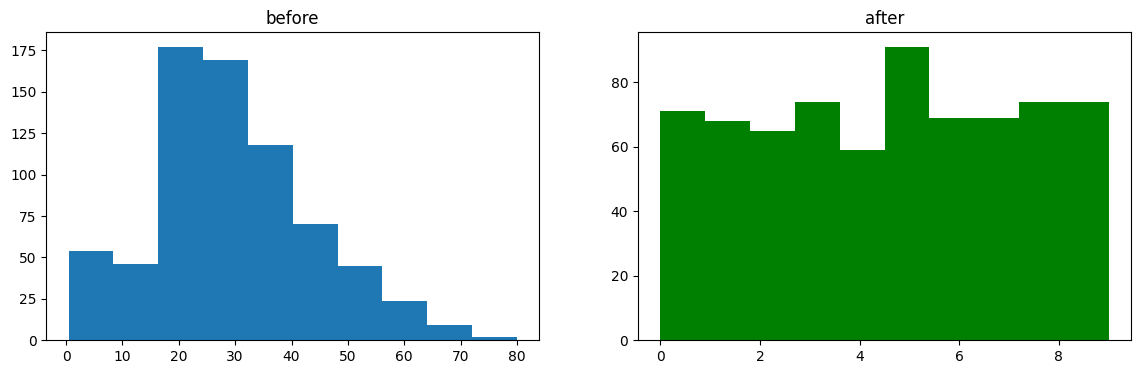

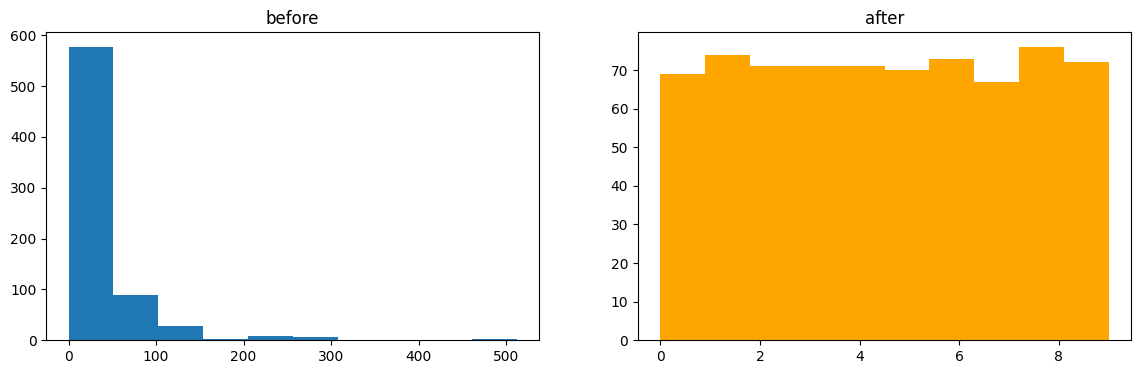

In [73]:
discretize(10,'quantile')

0.6373435054773082


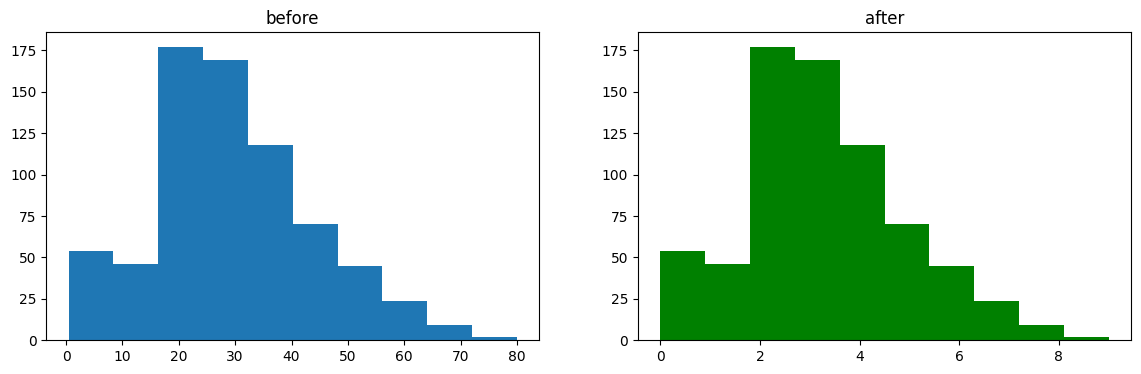

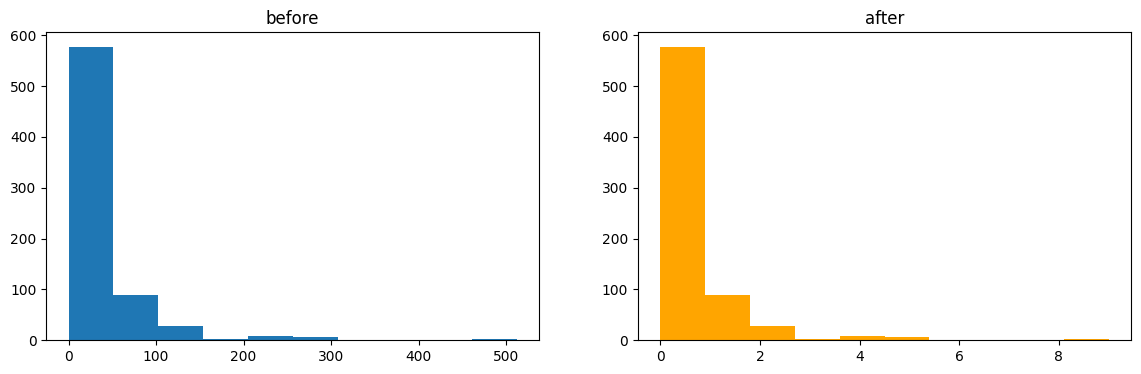

In [74]:
discretize(10, 'uniform')

0.6261150234741784


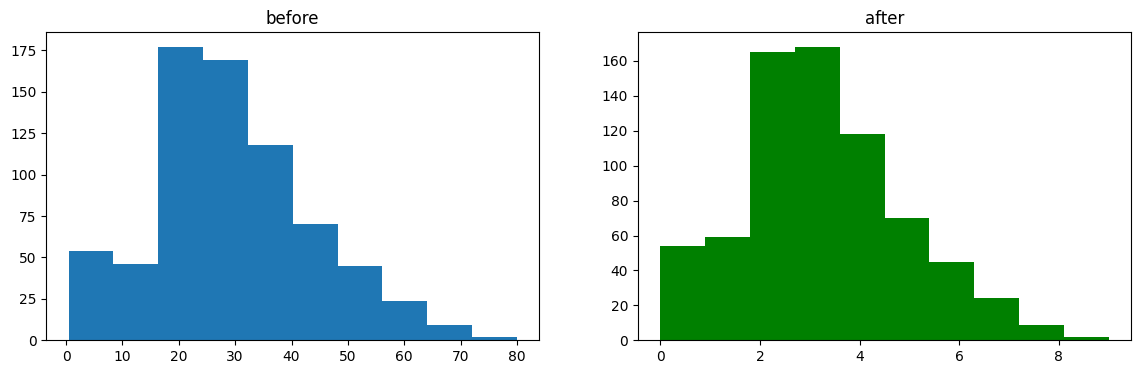

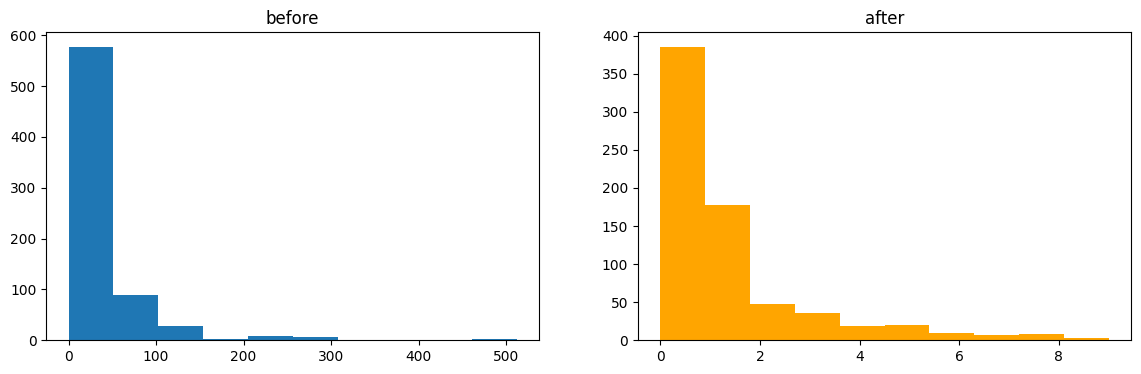

In [76]:
discretize(10, 'kmeans')